## **NUESTRA PRIMERA RED NEURONAL: MNIST DATASET**

In [ ]:
!pip install $packageName

In [1]:
!pip freeze

absl-py==1.4.0
aiohttp==3.9.3
aiosignal==1.3.1
alabaster==0.7.16
albumentations==1.3.1
altair==4.2.2
annotated-types==0.6.0
anyio==3.7.1
appdirs==1.4.4
argon2-cffi==23.1.0
argon2-cffi-bindings==21.2.0
array-record==0.5.0
arviz==0.15.1
astropy==5.3.4
astunparse==1.6.3
async-timeout==4.0.3
atpublic==4.0
attrs==23.2.0
audioread==3.0.1
autograd==1.6.2
Babel==2.14.0
backcall==0.2.0
beautifulsoup4==4.12.3
bidict==0.23.1
bigframes==0.22.0
bleach==6.1.0
blinker==1.4
blis==0.7.11
blosc2==2.0.0
bokeh==3.3.4
bqplot==0.12.43
branca==0.7.1
build==1.0.3
CacheControl==0.14.0
cachetools==5.3.3
catalogue==2.0.10
certifi==2024.2.2
cffi==1.16.0
chardet==5.2.0
charset-normalizer==3.3.2
chex==0.1.85
click==8.1.7
click-plugins==1.1.1
cligj==0.7.2
cloudpathlib==0.16.0
cloudpickle==2.2.1
cmake==3.27.9
cmdstanpy==1.2.1
colorcet==3.0.1
colorlover==0.3.0
colour==0.1.5
community==1.0.0b1
confection==0.1.4
cons==0.4.6
contextlib2==21.6.0
contourpy==1.2.0
cryptography==42.0.5
cufflinks==0.17.3
cupy-cuda12x==12.2.0


Hola voy a ejecutar el comando ```!pip freeze``` para cotillear a Google Colab

In [2]:
!nvidia-smi

Mon Mar  4 20:08:26 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.104.05             Driver Version: 535.104.05   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  Tesla T4                       Off | 00000000:00:04.0 Off |                    0 |
| N/A   44C    P8               9W /  70W |      0MiB / 15360MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

In [3]:
#Importemos TensorFlow 2.X y Numpy
import numpy as np
import tensorflow as tf
tf.__version__

'2.15.0'

#### **- Cargando el conjunto de datos**

In [4]:
# Importamos el dataset MNIST y cargamos los datos
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

11490434/11490434 [==============================] - 0s 0us/step
(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


#### **- Inspeccionando el conjunto de datos**

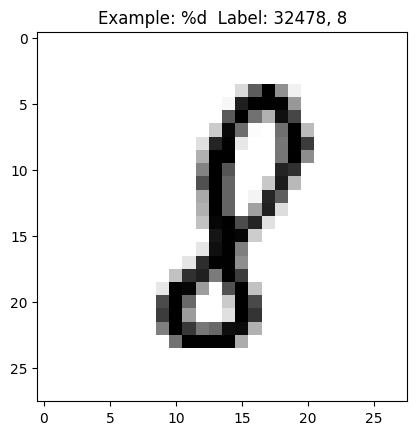

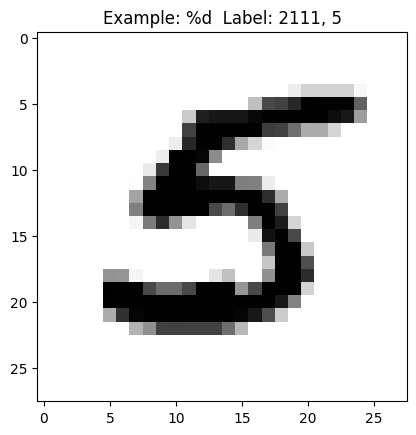

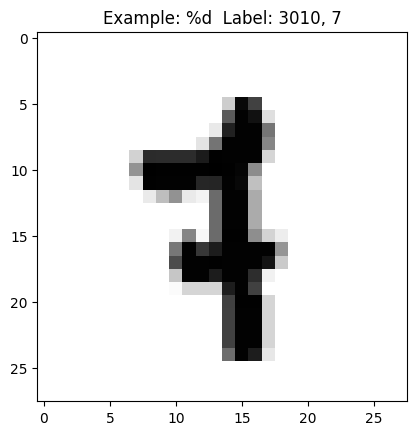

In [7]:
import matplotlib.pyplot as plt
# Función auxiliar para visualizar datos de entrenamiento de manera aleatoria
def display_digit(num,x_train,y_train):
  # Seleccionar la imagen num de mnist.train.images y hacer un reshape al tamaño de la imagen
  image = x_train[num,:,:]
  # Seleccionar el target num de mnist.train.labels
  label = y_train[num]
  # Mostrar
  plt.title(f'Example: %d  Label: {num}, {label}')
  plt.imshow(image, cmap=plt.get_cmap('gray_r'))
  plt.show()

# Mostramos algunos ejemplos
display_digit(np.random.randint(0, x_train.shape[0]),x_train,y_train)
display_digit(np.random.randint(0, x_train.shape[0]),x_train,y_train)
display_digit(np.random.randint(0, x_train.shape[0]),x_train,y_train)

In [ ]:
np.random.randint(0, x_train.shape[0])

#### **- Acondicionando el conjunto de datos**

In [8]:
# Pre-procesado obligatorio cuando trabajo con redes neuronales
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

x_train, x_te = x_train / 255.0, x_test / 255.0 #Cambio al rango 0-1 -> Disminuyo CC
y_train = to_categorical(y_train, num_classes=10) #One-hot encoding para minimizar error
print(y_train.shape)
y_te = to_categorical(y_test, num_classes=10)
x_tr, x_val, y_tr, y_val = train_test_split(x_train, y_train, test_size=0.1, random_state=42) # 3 subconjuntos es de vital importancia
print(y_tr.shape)
# print(y_tr[0])

(60000, 10)
(54000, 10)


In [9]:
print(y_tr[5214])

[0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]


In [10]:
print(y_tr[5214].argmax(axis=0))

4


In [ ]:
display_digit(5214, x_tr,y_tr)

#### **- Creando la topología de Red Neuronal (MLP) y entrenándola**

In [12]:
# Voy a necesitar importar una serie de modulos para programar mi red neuronal
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Input, Dropout
# Vamos a codificar la topología de nuestra primera red neuronal!!!
model = Sequential()
model.add(Flatten(input_shape=(28,28)))
model.add(Dense(512, input_shape=(28*28,), activation="relu"))
model.add(Dense(10, activation="softmax")) #Capa salida -> Mismo número de neuronas que de clases objetivo

# Ahí tenemos nuestro primer MLP con una única capa oculta de 512 neuronas

In [13]:
#Traigamos nuestro optimizador
from tensorflow.keras.optimizers import SGD
# Ahora que tengo definida la arquitectura, la compilo
model.compile(loss="categorical_crossentropy", optimizer=SGD(0.005), metrics=["accuracy"])

In [ ]:
######### Modelo funcional ############ (Clase 04/10/2023)
# Definir la entrada
input_layer = Input(shape=(28, 28))
# Capa de aplanamiento
x = Flatten()(input_layer)
x = Dense(512, activation="relu")(x)
# x= Dropout(0.5)(x) Introducción de capa de dropout en un modelo funcional
output_layer = Dense(10, activation="softmax")(x)
# Crear el modelo
model = Model(inputs=input_layer, outputs=output_layer)

In [14]:
print(model.summary())

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_1 (Flatten)         (None, 784)               0         
                                                                 
 dense_2 (Dense)             (None, 512)               401920    
                                                                 
 dense_3 (Dense)             (None, 10)                5130      
                                                                 
Total params: 407050 (1.55 MB)
Trainable params: 407050 (1.55 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
None


In [15]:
# Por fin podemos entrenar nuestra primera red neuronal
print("[INFO]: Entrenando red neuronal...")
H = model.fit(x_tr, y_tr, validation_data=(x_val, y_val), epochs=50, batch_size=128)

[INFO]: Entrenando red neuronal...
Epoch 1/50
422/422 [==============================] - 3s 4ms/step - loss: 1.5764 - accuracy: 0.6293 - val_loss: 1.0466 - val_accuracy: 0.8025
Epoch 2/50
422/422 [==============================] - 1s 3ms/step - loss: 0.8289 - accuracy: 0.8302 - val_loss: 0.6875 - val_accuracy: 0.8498
Epoch 3/50
422/422 [==============================] - 1s 3ms/step - loss: 0.6106 - accuracy: 0.8595 - val_loss: 0.5526 - val_accuracy: 0.8672
Epoch 4/50
422/422 [==============================] - 1s 3ms/step - loss: 0.5152 - accuracy: 0.8743 - val_loss: 0.4828 - val_accuracy: 0.8815
Epoch 5/50
422/422 [==============================] - 1s 3ms/step - loss: 0.4611 - accuracy: 0.8837 - val_loss: 0.4396 - val_accuracy: 0.8888
Epoch 6/50
422/422 [==============================] - 1s 3ms/step - loss: 0.4257 - accuracy: 0.8900 - val_loss: 0.4091 - val_accuracy: 0.8943
Epoch 7/50
422/422 [==============================] - 2s 4ms/step - loss: 0.4004 - accuracy: 0.8945 - val_loss: 0

#### **- Observando el proceso de entrenamiento para tomar decisiones**

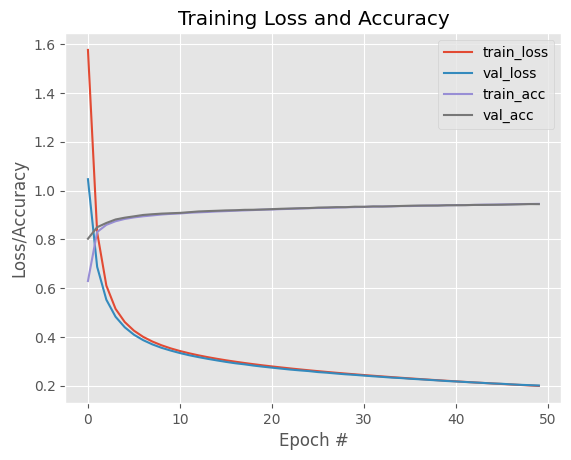

In [16]:
# Muestro gráfica de accuracy y losses
plt.style.use("ggplot")
plt.figure()
plt.plot(np.arange(0, 50), H.history["loss"], label="train_loss")
plt.plot(np.arange(0, 50), H.history["val_loss"], label="val_loss")
plt.plot(np.arange(0, 50), H.history["accuracy"], label="train_acc")
plt.plot(np.arange(0, 50), H.history["val_accuracy"], label="val_acc")
plt.title("Training Loss and Accuracy")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend()

#### **- Probando el conjunto de datos en el subset de test y evaluando el performance del modelo**

In [17]:
from sklearn.metrics import classification_report
# Evaluando el modelo de predicción con las imágenes de test
print("[INFO]: Evaluando red neuronal...")
predictions = model.predict(x_te, batch_size=128)
print(y_te[0])
print(predictions[0])
print(classification_report(y_te.argmax(axis=1), predictions.argmax(axis=1)))

[INFO]: Evaluando red neuronal...
79/79 [==============================] - 0s 2ms/step
[0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
[8.6496279e-05 2.2646141e-07 4.7658369e-04 2.2703437e-03 1.7342688e-06
 1.0547713e-04 1.0057563e-07 9.9665856e-01 2.2058515e-05 3.7848466e-04]
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       980
           1       0.98      0.98      0.98      1135
           2       0.94      0.93      0.94      1032
           3       0.93      0.94      0.93      1010
           4       0.93      0.95      0.94       982
           5       0.94      0.90      0.92       892
           6       0.94      0.96      0.95       958
           7       0.94      0.93      0.94      1028
           8       0.92      0.93      0.93       974
           9       0.93      0.91      0.92      1009

    accuracy                           0.94     10000
   macro avg       0.94      0.94      0.94     10000
weighted avg       0.94      0.94 

In [ ]:
predictions[0].argmax(axis=0)

In [ ]:
y_te[0].argmax(axis=0)

In [ ]:
print(model.summary())

--------------------------------------------------------------------------

## **MLP APLICADO A TEXTO: EJEMPLO REUTERS**

#### **- Cargando el conjunto de datos**

In [1]:
import numpy as np
import tensorflow as tf
# Importamos el dataset REUTERS y cargamos los datos
reuters = tf.keras.datasets.reuters
WORD_LIMIT = 10000
(training_data, training_labels), (testing_data, testing_labels) = reuters.load_data(num_words=WORD_LIMIT)
print(training_data.shape)
print(training_labels.shape)
print(testing_data.shape)
print(testing_labels.shape)

2110848/2110848 [==============================] - 0s 0us/step
(8982,)
(8982,)
(2246,)
(2246,)


#### **- Inspeccionando el conjunto de datos**

In [2]:
# Los datos son numericos para decodificarlos, se puede usar reuters.get_word_index()
word_index = reuters.get_word_index()
reverse_word_index = dict({value : key for key, value in word_index.items()})
decoded = ' '.join(
    [reverse_word_index.get(i-3,'?') for i in training_data[5]]
)
decoded

550378/550378 [==============================] - 0s 0us/step


"? the u s agriculture department estimated canada's 1986 87 wheat crop at 31 85 mln tonnes vs 31 85 mln tonnes last month it estimated 1985 86 output at 24 25 mln tonnes vs 24 25 mln last month canadian 1986 87 coarse grain production is projected at 27 62 mln tonnes vs 27 62 mln tonnes last month production in 1985 86 is estimated at 24 95 mln tonnes vs 24 95 mln last month canadian wheat exports in 1986 87 are forecast at 19 00 mln tonnes vs 18 00 mln tonnes last month exports in 1985 86 are estimated at 17 71 mln tonnes vs 17 72 mln last month reuter 3"

#### **- Acondicionando el conjunto de datos**

In [3]:
# Función auxiliar para representar las palabras (que no entiende nuestra red neuronal) en números
import numpy as np
# one hot encoding del input, vector con cada indice indicando si una palabra esta presente
def one_hot_encode(data):
    encoded = np.zeros((len(data),WORD_LIMIT))
    for i, v in enumerate(data):
        encoded[i,v] = 1 # localiza las columnas del genero correspondiente, marca con 1
    return encoded

In [4]:
# Convertimos nuestras palabras a números
x_train = one_hot_encode(training_data)
x_test = one_hot_encode(testing_data)
print(x_train.shape)
print(x_test.shape)

(8982, 10000)
(2246, 10000)


In [5]:
print(x_test[3])

[0. 1. 1. ... 0. 0. 0.]


In [6]:
# Convertimos nuestros labels (categoría reseña) a one-hot encoding
from tensorflow.keras.utils import to_categorical
y_train = to_categorical(training_labels)
y_test = to_categorical(testing_labels)
print(y_train.shape)
print(y_test.shape)

(8982, 46)
(2246, 46)


In [ ]:
print(y_test[3])

#### **- Creando la topología de Red Neuronal (MLP) y entrenándola**

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
# Vamos a codificar la topología de nuestro MLP
model = Sequential()
model.add(Dense(128,activation='relu',input_shape=(WORD_LIMIT,)))
model.add(Dense(64,activation='relu'))
model.add(Dense(46,activation='softmax')) # Reparto de la unidad de probabilidad entre num_classes
# En el caso de regresión cambiamos la ultima capa por:
#model.add(Dense(1,activation='sigmoid'))

In [8]:
# Ahora que tengo definida la arquitectura, la compilo
model.compile(optimizer='adam',
               loss='categorical_crossentropy', # ideal para clasificacion multiclase/ para regresion (mse/mae)
               metrics=['accuracy'])

In [9]:
# A entrenar nuestra red neuronal sea dicho!
H = model.fit(x_train,y_train,epochs=20,batch_size=32, validation_split=0.2)

Epoch 1/20
225/225 [==============================] - 4s 8ms/step - loss: 1.4582 - accuracy: 0.6902 - val_loss: 0.9889 - val_accuracy: 0.7841
Epoch 2/20
225/225 [==============================] - 1s 4ms/step - loss: 0.5585 - accuracy: 0.8757 - val_loss: 0.9206 - val_accuracy: 0.7902
Epoch 3/20
225/225 [==============================] - 1s 4ms/step - loss: 0.2791 - accuracy: 0.9417 - val_loss: 0.9346 - val_accuracy: 0.8091
Epoch 4/20
225/225 [==============================] - 1s 4ms/step - loss: 0.1950 - accuracy: 0.9546 - val_loss: 0.9380 - val_accuracy: 0.8024
Epoch 5/20
225/225 [==============================] - 1s 4ms/step - loss: 0.1585 - accuracy: 0.9588 - val_loss: 0.9429 - val_accuracy: 0.8024
Epoch 6/20
225/225 [==============================] - 1s 4ms/step - loss: 0.1416 - accuracy: 0.9589 - val_loss: 1.0260 - val_accuracy: 0.7908
Epoch 7/20
225/225 [==============================] - 1s 4ms/step - loss: 0.1285 - accuracy: 0.9599 - val_loss: 1.0363 - val_accuracy: 0.7997
Epoch 

#### **- Observando el proceso de entrenamiento para tomar decisiones**

In [11]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 128)               1280128   
                                                                 
 dense_1 (Dense)             (None, 64)                8256      
                                                                 
 dense_2 (Dense)             (None, 46)                2990      
                                                                 
Total params: 1291374 (4.93 MB)
Trainable params: 1291374 (4.93 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


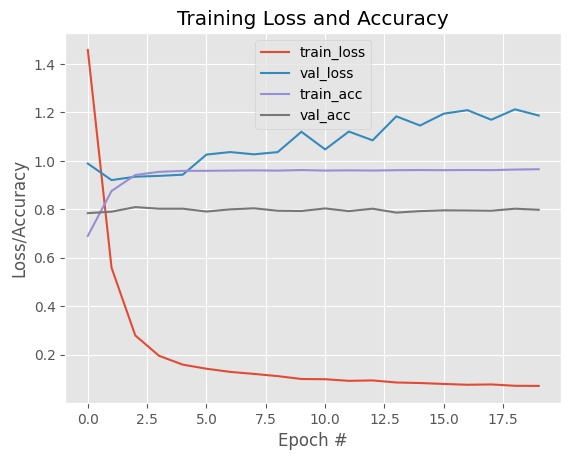

In [10]:
import matplotlib.pyplot as plt
# Muestro gráfica de accuracy y losses
plt.style.use("ggplot")
plt.figure()
plt.plot(np.arange(0, 20), H.history["loss"], label="train_loss")
plt.plot(np.arange(0, 20), H.history["val_loss"], label="val_loss")
plt.plot(np.arange(0, 20), H.history["accuracy"], label="train_acc")
plt.plot(np.arange(0, 20), H.history["val_accuracy"], label="val_acc")
plt.title("Training Loss and Accuracy")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend()

#### **- Probando el conjunto de datos en el subset de test y evaluando el performance del modelo**

In [12]:
# Evaluando el modelo de predicción con las imágenes de test
print("[INFO]: Evaluando red neuronal...")
model.predict(x_test)
loss, accuracy = model.evaluate(x_test, y_test)
print('Loss {}, accuracy {}'.format(loss,accuracy))

[INFO]: Evaluando red neuronal...
71/71 [==============================] - 0s 3ms/step - loss: 1.2920 - accuracy: 0.7907
Loss 1.292013168334961, accuracy 0.790739119052887


## **REGULARIZACIÓN EN APRENDIZAJE PROFUNDO**

#### **- Weight regularization L1/L2**

In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras import regularizers
# Vamos a codificar la topología de nuestro MLP
model_reg = Sequential()
model_reg.add(Dense(128,activation='relu', kernel_regularizer=regularizers.l2(0.01), input_shape=(WORD_LIMIT,)))
model_reg.add(Dense(64,activation='relu', kernel_regularizer=regularizers.l2(0.01)))
model_reg.add(Dense(46,activation='softmax')) # Reparto de la unidad de probabilidad entre num_classes

In [14]:
# Ahora que tengo definida la arquitectura, la compilo
model_reg.compile(optimizer='adam',
               loss='categorical_crossentropy', # ideal para clasificacion multiclase
               metrics=['accuracy'])

In [15]:
# A entrenar nuestra red neuronal sea dicho!
H = model_reg.fit(x_train,y_train,epochs=20,batch_size=32, validation_split=0.2)

Epoch 1/20
225/225 [==============================] - 2s 6ms/step - loss: 2.3993 - accuracy: 0.6444 - val_loss: 1.8018 - val_accuracy: 0.7162
Epoch 2/20
225/225 [==============================] - 1s 4ms/step - loss: 1.6930 - accuracy: 0.7297 - val_loss: 1.6862 - val_accuracy: 0.7485
Epoch 3/20
225/225 [==============================] - 1s 4ms/step - loss: 1.5923 - accuracy: 0.7507 - val_loss: 1.6466 - val_accuracy: 0.7396
Epoch 4/20
225/225 [==============================] - 1s 4ms/step - loss: 1.5389 - accuracy: 0.7626 - val_loss: 1.6259 - val_accuracy: 0.7585
Epoch 5/20
225/225 [==============================] - 1s 4ms/step - loss: 1.4944 - accuracy: 0.7730 - val_loss: 1.5709 - val_accuracy: 0.7546
Epoch 6/20
225/225 [==============================] - 1s 4ms/step - loss: 1.4619 - accuracy: 0.7759 - val_loss: 1.5849 - val_accuracy: 0.7529
Epoch 7/20
225/225 [==============================] - 1s 4ms/step - loss: 1.4370 - accuracy: 0.7861 - val_loss: 1.5282 - val_accuracy: 0.7724
Epoch 

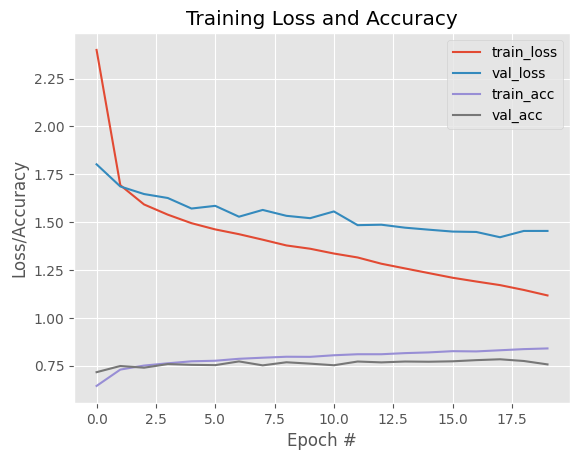

In [16]:
import matplotlib.pyplot as plt
# Muestro gráfica de accuracy y losses
plt.style.use("ggplot")
plt.figure()
plt.plot(np.arange(0, 20), H.history["loss"], label="train_loss")
plt.plot(np.arange(0, 20), H.history["val_loss"], label="val_loss")
plt.plot(np.arange(0, 20), H.history["accuracy"], label="train_acc")
plt.plot(np.arange(0, 20), H.history["val_accuracy"], label="val_acc")
plt.title("Training Loss and Accuracy")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend()

In [17]:
# Evaluando el modelo de predicción con las imágenes de test
print("[INFO]: Evaluando red neuronal...")
model_reg.predict(x_test)
loss, accuracy = model_reg.evaluate(x_test, y_test)
print('Loss {}, accuracy {}'.format(loss,accuracy))

[INFO]: Evaluando red neuronal...
71/71 [==============================] - 0s 3ms/step - loss: 1.4939 - accuracy: 0.7542
Loss 1.4939252138137817, accuracy 0.754229724407196


#### **- Dropout**

In [21]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
# Vamos a codificar la topología de nuestro MLP
model_drop = Sequential()
model_drop.add(Dense(128,activation='relu', input_shape=(WORD_LIMIT,)))
#model_drop.add(Dropout(0.5))
model_drop.add(Dropout(0.55))
model_drop.add(Dense(64,activation='relu'))
#model_drop.add(Dropout(0.5))
model_drop.add(Dropout(0.55))
model_drop.add(Dense(46,activation='softmax')) # Reparto de la unidad de probabilidad entre num_classes

In [23]:
# Ahora que tengo definida la arquitectura, la compilo
model_drop.compile(optimizer='adam',
               loss='categorical_crossentropy', # ideal para clasificacion multiclase
               metrics=['accuracy'])

In [24]:
# A entrenar nuestra red neuronal sea dicho!
H = model_drop.fit(x_train,y_train,epochs=20,batch_size=32, validation_split=0.2)

Epoch 1/20
225/225 [==============================] - 2s 6ms/step - loss: 2.0361 - accuracy: 0.5132 - val_loss: 1.3255 - val_accuracy: 0.7045
Epoch 2/20
225/225 [==============================] - 1s 4ms/step - loss: 1.3501 - accuracy: 0.6800 - val_loss: 1.1474 - val_accuracy: 0.7318
Epoch 3/20
225/225 [==============================] - 1s 4ms/step - loss: 1.1319 - accuracy: 0.7310 - val_loss: 1.0709 - val_accuracy: 0.7691
Epoch 4/20
225/225 [==============================] - 1s 6ms/step - loss: 0.9453 - accuracy: 0.7669 - val_loss: 1.0094 - val_accuracy: 0.7846
Epoch 5/20
225/225 [==============================] - 1s 6ms/step - loss: 0.8397 - accuracy: 0.7930 - val_loss: 0.9916 - val_accuracy: 0.7885
Epoch 6/20
225/225 [==============================] - 1s 5ms/step - loss: 0.7424 - accuracy: 0.8149 - val_loss: 0.9743 - val_accuracy: 0.7991
Epoch 7/20
225/225 [==============================] - 1s 5ms/step - loss: 0.6926 - accuracy: 0.8227 - val_loss: 1.0009 - val_accuracy: 0.7974
Epoch 

In [ ]:
import matplotlib.pyplot as plt
# Muestro gráfica de accuracy y losses
plt.style.use("ggplot")
plt.figure()
plt.plot(np.arange(0, 20), H.history["loss"], label="train_loss")
plt.plot(np.arange(0, 20), H.history["val_loss"], label="val_loss")
plt.plot(np.arange(0, 20), H.history["accuracy"], label="train_acc")
plt.plot(np.arange(0, 20), H.history["val_accuracy"], label="val_acc")
plt.title("Training Loss and Accuracy")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend()

# ¿Y si desconectamos mayor porcentaje de neuronas?

In [ ]:
# Evaluando el modelo de predicción con las imágenes de test
print("[INFO]: Evaluando red neuronal...")
model_drop.predict(x_test)
loss, accuracy = model_drop.evaluate(x_test, y_test)
print('Loss {}, accuracy {}'.format(loss,accuracy))

#### **- Batch Normalization**

In [25]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization
# Vamos a codificar la topología de nuestro MLP
model_bn = Sequential()
model_bn.add(Dense(128,activation='relu', input_shape=(WORD_LIMIT,)))
model_bn.add(BatchNormalization())
model_bn.add(Dropout(0.6))
model_bn.add(Dense(64,activation='relu'))
model_bn.add(BatchNormalization())
model_bn.add(Dropout(0.6))
model_bn.add(Dense(46,activation='softmax')) # Reparto de la unidad de probabilidad entre num_classes

In [26]:
# Ahora que tengo definida la arquitectura, la compilo
model_bn.compile(optimizer='adam',
               loss='categorical_crossentropy', # ideal para clasificacion multiclase
               metrics=['accuracy'])

In [27]:
# A entrenar nuestra red neuronal sea dicho!
H = model_bn.fit(x_train,y_train,epochs=20,batch_size=32, validation_split=0.2)

Epoch 1/20
225/225 [==============================] - 5s 10ms/step - loss: 2.5322 - accuracy: 0.4732 - val_loss: 1.6051 - val_accuracy: 0.7123
Epoch 2/20
225/225 [==============================] - 1s 6ms/step - loss: 1.5540 - accuracy: 0.6669 - val_loss: 1.2152 - val_accuracy: 0.7485
Epoch 3/20
225/225 [==============================] - 1s 7ms/step - loss: 1.2689 - accuracy: 0.7198 - val_loss: 1.1293 - val_accuracy: 0.7590
Epoch 4/20
225/225 [==============================] - 1s 6ms/step - loss: 1.0926 - accuracy: 0.7463 - val_loss: 1.0657 - val_accuracy: 0.7763
Epoch 5/20
225/225 [==============================] - 1s 6ms/step - loss: 0.9873 - accuracy: 0.7711 - val_loss: 1.0266 - val_accuracy: 0.7885
Epoch 6/20
225/225 [==============================] - 1s 6ms/step - loss: 0.8882 - accuracy: 0.7887 - val_loss: 0.9851 - val_accuracy: 0.7941
Epoch 7/20
225/225 [==============================] - 1s 6ms/step - loss: 0.8085 - accuracy: 0.8050 - val_loss: 0.9495 - val_accuracy: 0.7969
Epoch

In [ ]:
import matplotlib.pyplot as plt
# Muestro gráfica de accuracy y losses
plt.style.use("ggplot")
plt.figure()
plt.plot(np.arange(0, 20), H.history["loss"], label="train_loss")
plt.plot(np.arange(0, 20), H.history["val_loss"], label="val_loss")
plt.plot(np.arange(0, 20), H.history["accuracy"], label="train_acc")
plt.plot(np.arange(0, 20), H.history["val_accuracy"], label="val_acc")
plt.title("Training Loss and Accuracy")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend()

In [ ]:
# Evaluando el modelo de predicción con las imágenes de test
print("[INFO]: Evaluando red neuronal...")
model_bn.predict(x_test)
loss, accuracy = model_bn.evaluate(x_test, y_test)
print('Loss {}, accuracy {}'.format(loss,accuracy))